# Post Test Praktikum Algoritma dan Pemrograman 2026

## Kelas F - Student AI Usage - Kelompok 4

Notebook ini memakai gaya visualisasi dari file referensi `AI_USAGE - Copy/post_test_kelompok_4.py`. Setiap kategori dikerjakan pada block code terpisah, lalu block terakhir membuat grafik gabungan 2 x 2 menggunakan `axes[x, y]`.

## 1. Import Library dan Helper Visualisasi

In [1]:
from pathlib import Path

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / "data" / "Kelas F_Student AI Usage.csv"
OUTPUT_DIR = BASE_DIR / "hasil_kelompok_4"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial', 'DejaVu Sans', 'Calibri', 'sans-serif']
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['text.color'] = '#1E293B'
plt.rcParams['axes.labelcolor'] = '#475569'
plt.rcParams['xtick.color'] = '#1E293B'
plt.rcParams['ytick.color'] = '#1E293B'
sns.set_theme(style="whitegrid")

numeric_columns = [
    "age",
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
]

def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Grafik disimpan: {path}")

def style_axis(ax, labelsize=11):
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#CBD5E1', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#94A3B8')
    ax.spines['bottom'].set_color('#94A3B8')
    ax.tick_params(axis='both', which='both', length=0, labelsize=labelsize)

def insight_box(fig, text, y=0.04):
    fig.text(
        0.5, y, text,
        ha='center', va='center', fontsize=9.5, color='#475569',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8FAFC', edgecolor='#E2E8F0')
    )

## 2. Load Dataset

In [2]:
df = pd.read_csv(CSV_PATH)

print(f"Memuat dataset: {CSV_PATH}")
print(f"Jumlah data: {len(df)} baris")
print(f"Kolom: {', '.join(df.columns)}")
display(df.head())

Memuat dataset: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/data/Kelas F_Student AI Usage.csv
Jumlah data: 100 baris
Kolom: age, education_level, study_hours_per_day, uses_ai, ai_tools_used, purpose_of_ai, grades_before_ai, grades_after_ai, daily_screen_time_hours


,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


## 3. Grafik 1 - Kategori A (Agregasi)

Tentukan median nilai `grades_before_ai` berdasarkan jenjang pendidikan (`education_level`).

Kategori A - Median grades_before_ai berdasarkan education_level


,education_level,grades_before_ai
1,school,64.5
0,college,63.0


Grafik disimpan: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/hasil_kelompok_4/01_kategori_a_median_grades_before.png


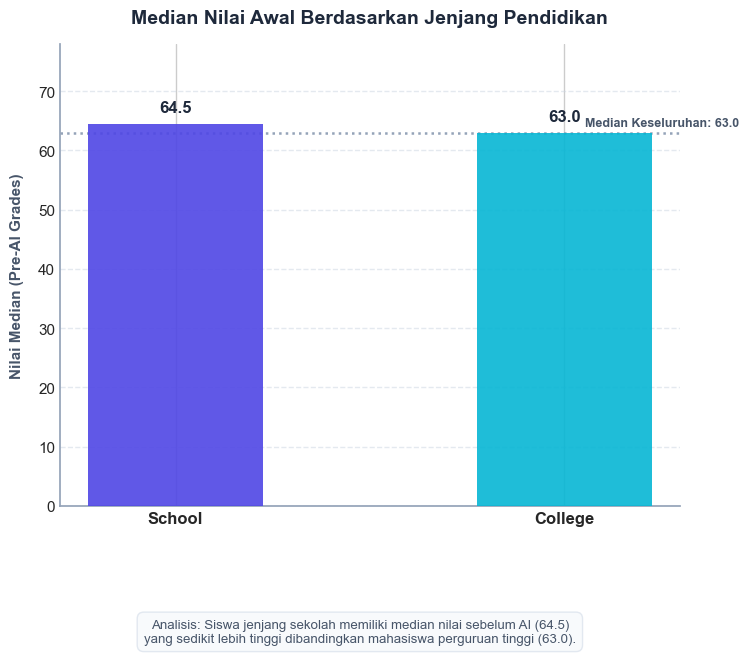

In [3]:
median_grades = (
    df.groupby("education_level")["grades_before_ai"]
    .median()
    .reset_index()
    .sort_values("grades_before_ai", ascending=False)
)

print("Kategori A - Median grades_before_ai berdasarkan education_level")
display(median_grades)

fig, ax = plt.subplots(figsize=(8, 7))
fig.subplots_adjust(bottom=0.22)

colors = ['#4F46E5', '#06B6D4']
bars = ax.bar(
    median_grades["education_level"],
    median_grades["grades_before_ai"],
    color=colors,
    width=0.45,
    edgecolor='none',
    alpha=0.9,
    zorder=3
)

style_axis(ax, labelsize=11)
ax.set_xticks(range(len(median_grades)))
ax.set_xticklabels([x.capitalize() for x in median_grades["education_level"]], fontweight='bold', fontsize=12)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#1E293B'
    )

overall_median = df['grades_before_ai'].median()
ax.axhline(overall_median, color='#94A3B8', linestyle=':', linewidth=1.8, zorder=2)
ax.text(
    len(median_grades) - 0.55, overall_median + 1.2,
    f'Median Keseluruhan: {overall_median:.1f}',
    color='#475569', fontsize=9, fontweight='semibold', ha='right', zorder=4
)

ax.set_title(
    "Median Nilai Awal Berdasarkan Jenjang Pendidikan",
    fontsize=14, fontweight='bold', color='#1E293B', pad=15
)
ax.set_ylabel("Nilai Median (Pre-AI Grades)", fontsize=11, fontweight='semibold', color='#475569', labelpad=10)
ax.set_ylim(0, 78)

insight_box(
    fig,
    "Analisis: Siswa jenjang sekolah memiliki median nilai sebelum AI (64.5)\n"
    "yang sedikit lebih tinggi dibandingkan mahasiswa perguruan tinggi (63.0).",
    y=0.04
)
save_figure(fig, "01_kategori_a_median_grades_before.png")
plt.show()
plt.close(fig)

## 4. Grafik 2 - Kategori B (Filter)

Cari siswa yang menggunakan AI untuk `Homework` tetapi waktu belajar mandirinya di bawah 2 jam.

Kategori B - Siswa purpose_of_ai Homework dan study_hours_per_day < 2


,student_label,age,education_level,ai_tools_used,study_hours_per_day,grades_before_ai,grades_after_ai,grade_improvement
2,Siswa 3,15,school,Copilot,1.9,75,88,13
8,Siswa 9,19,college,Gemini,1.3,62,68,6
33,Siswa 34,14,school,ChatGPT,1.3,56,66,10
46,Siswa 47,15,school,ChatGPT,1.2,74,80,6
61,Siswa 62,14,school,Copilot,1.3,66,80,14
72,Siswa 73,18,college,Gemini,1.5,68,73,5


Grafik disimpan: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/hasil_kelompok_4/02_kategori_b_homework_under_2_hours.png


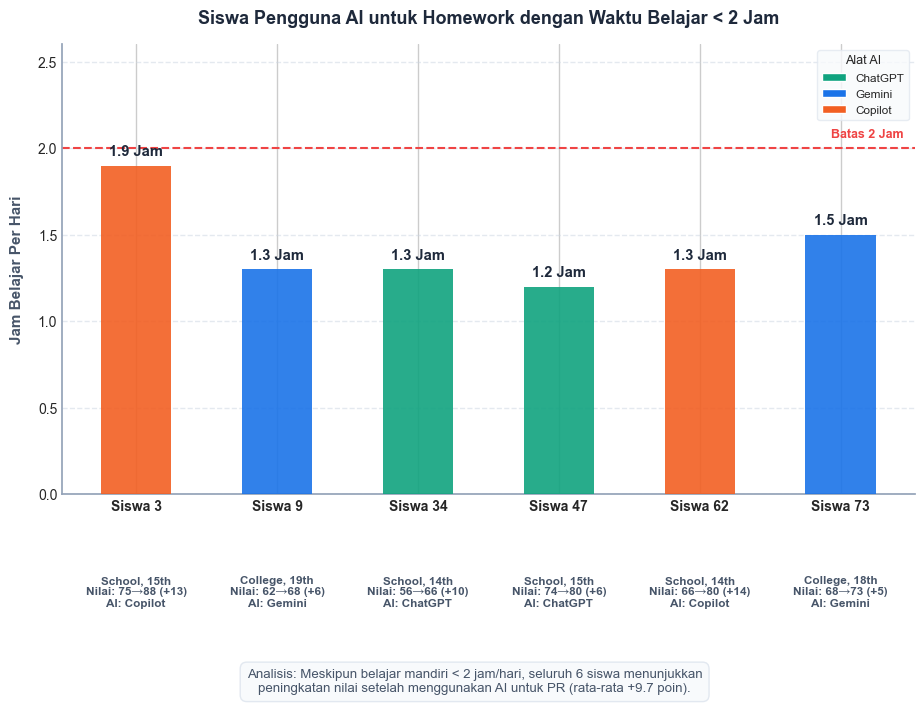

In [4]:
filtered = df[
    (df["purpose_of_ai"] == "Homework")
    & (df["study_hours_per_day"] < 2)
].copy()
filtered["student_label"] = [f"Siswa {i + 1}" for i in filtered.index]
filtered["grade_improvement"] = filtered["grades_after_ai"] - filtered["grades_before_ai"]

print("Kategori B - Siswa purpose_of_ai Homework dan study_hours_per_day < 2")
display(filtered[["student_label", "age", "education_level", "ai_tools_used", "study_hours_per_day", "grades_before_ai", "grades_after_ai", "grade_improvement"]])

fig, ax = plt.subplots(figsize=(11, 7.5))
fig.subplots_adjust(bottom=0.28)

tool_colors = {
    "ChatGPT": "#10A37F",
    "Gemini": "#1A73E8",
    "Copilot": "#F25F22"
}
colors = [tool_colors.get(tool, "#64748B") for tool in filtered["ai_tools_used"]]

bars = ax.bar(
    range(len(filtered)),
    filtered["study_hours_per_day"],
    color=colors,
    width=0.50,
    edgecolor='none',
    alpha=0.9,
    zorder=3
)

style_axis(ax, labelsize=10)
ax.set_xticks(range(len(filtered)))
ax.set_xticklabels(filtered["student_label"].tolist(), fontweight='semibold', fontsize=10)

ax.axhline(2.0, color='#EF4444', linestyle='--', linewidth=1.5, zorder=2)
ax.text(
    len(filtered) - 0.55, 2.06,
    "Batas 2 Jam",
    color='#EF4444', fontsize=9, fontweight='bold', ha='right', zorder=4
)

for i, (bar, (_, row)) in enumerate(zip(bars, filtered.iterrows())):
    height = bar.get_height()
    imp = row['grades_after_ai'] - row['grades_before_ai']
    ax.annotate(
        f"{height:.1f} Jam",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10.5, fontweight='bold', color='#1E293B'
    )
    ax.text(
        i, -0.18,
        f"{row['education_level'].capitalize()}, {row['age']}th\n"
        f"Nilai: {row['grades_before_ai']}→{row['grades_after_ai']} (+{imp})\n"
        f"AI: {row['ai_tools_used']}",
        ha='center', va='top', fontsize=8.5, color='#475569',
        fontweight='semibold',
        transform=ax.get_xaxis_transform()
    )

ax.set_title(
    "Siswa Pengguna AI untuk Homework dengan Waktu Belajar < 2 Jam",
    fontsize=13, fontweight='bold', color='#1E293B', pad=15
)

legend_elements = [
    Patch(facecolor=tool_colors["ChatGPT"], label='ChatGPT'),
    Patch(facecolor=tool_colors["Gemini"], label='Gemini'),
    Patch(facecolor=tool_colors["Copilot"], label='Copilot')
]
ax.legend(
    handles=legend_elements, title="Alat AI",
    title_fontsize=9, fontsize=8.5, loc='upper right',
    frameon=True, facecolor='#F8FAFC', edgecolor='#E2E8F0'
)

ax.set_ylabel("Jam Belajar Per Hari", fontsize=11, fontweight='semibold', color='#475569', labelpad=10)
ax.set_ylim(0, 2.6)

insight_box(
    fig,
    "Analisis: Meskipun belajar mandiri < 2 jam/hari, seluruh 6 siswa menunjukkan\n"
    "peningkatan nilai setelah menggunakan AI untuk PR (rata-rata +9.7 poin).",
    y=0.03
)
save_figure(fig, "02_kategori_b_homework_under_2_hours.png")
plt.show()
plt.close(fig)

## 5. Grafik 3 - Kategori C (Korelasi)

Hitung matriks korelasi antar seluruh kolom numerik dan tampilkan dalam Heatmap.

Kategori C - Matriks korelasi kolom numerik


,Umur\n(Age),Jam Belajar\n(Study Hours),Nilai Pre-AI\n(Before),Nilai Post-AI\n(After),Screen Time\n(Daily)
Umur\n(Age),1.000,0.011,-0.100,-0.050,0.259
Jam Belajar\n(Study Hours),0.011,1.000,0.171,0.075,-0.027
Nilai Pre-AI\n(Before),-0.100,0.171,1.000,0.756,0.078
Nilai Post-AI\n(After),-0.050,0.075,0.756,1.000,0.096
Screen Time\n(Daily),0.259,-0.027,0.078,0.096,1.000


Grafik disimpan: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/hasil_kelompok_4/03_kategori_c_correlation_heatmap.png


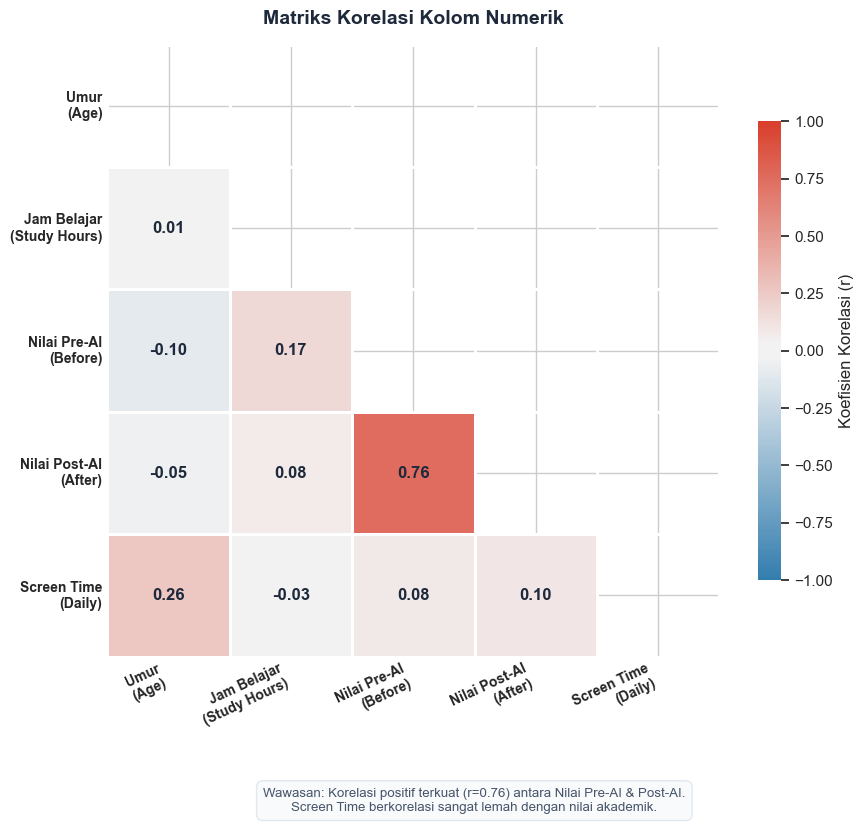

In [5]:
df_id = df[numeric_columns].copy()
df_id.columns = [
    "Umur\n(Age)",
    "Jam Belajar\n(Study Hours)",
    "Nilai Pre-AI\n(Before)",
    "Nilai Post-AI\n(After)",
    "Screen Time\n(Daily)"
]

corr_matrix = df_id.corr()
print("Kategori C - Matriks korelasi kolom numerik")
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(10, 9))
fig.subplots_adjust(bottom=0.20)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(240, 15, s=85, l=50, sep=10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmin=-1.0,
    vmax=1.0,
    annot=True,
    fmt=".2f",
    linewidths=2.0,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Koefisien Korelasi (r)"},
    ax=ax,
    annot_kws={"size": 12, "weight": "bold", "color": "#1E293B"}
)

ax.tick_params(axis='both', which='both', length=0, labelsize=10)
plt.xticks(rotation=25, ha='right', fontweight='semibold')
plt.yticks(rotation=0, fontweight='semibold')

ax.set_title(
    "Matriks Korelasi Kolom Numerik",
    fontsize=14, fontweight='bold', color='#1E293B', pad=15
)

insight_box(
    fig,
    "Wawasan: Korelasi positif terkuat (r=0.76) antara Nilai Pre-AI & Post-AI.\n"
    "Screen Time berkorelasi sangat lemah dengan nilai akademik.",
    y=0.04
)
save_figure(fig, "03_kategori_c_correlation_heatmap.png")
plt.show()
plt.close(fig)

## 6. Grafik 4 - Kategori D (Distribusi)

Tampilkan visualisasi bentuk distribusi umur siswa dalam lembar survei.

Kategori D - Distribusi umur siswa


count    100.000000
mean      16.490000
std        1.702612
min       14.000000
25%       15.000000
50%       16.000000
75%       18.000000
max       19.000000
Name: age, dtype: float64

Grafik disimpan: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/hasil_kelompok_4/04_kategori_d_age_distribution.png


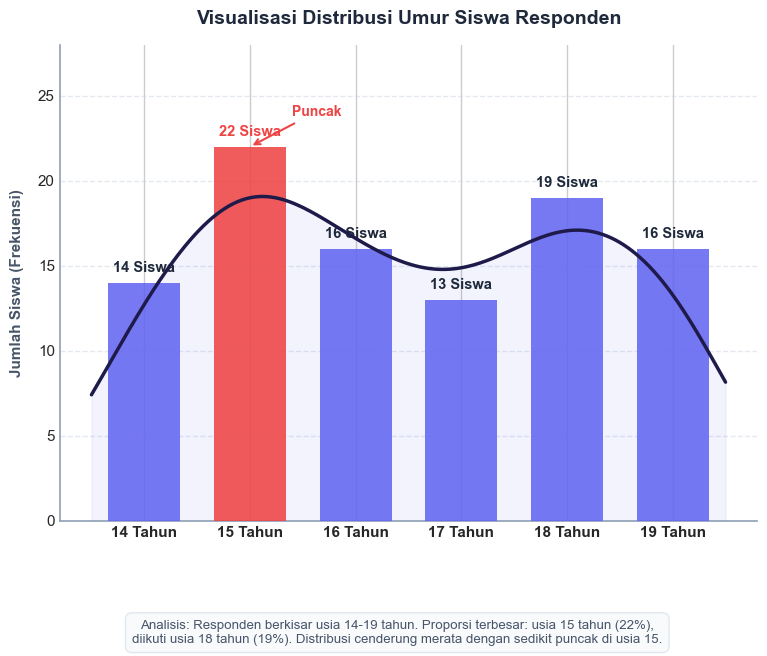

In [6]:
print("Kategori D - Distribusi umur siswa")
display(df["age"].describe())

fig, ax = plt.subplots(figsize=(9, 7))
fig.subplots_adjust(bottom=0.20)

age_counts = df["age"].value_counts().sort_index()
ages = age_counts.index
counts = age_counts.values
max_idx = np.argmax(counts)
age_colors = ['#6366F1' if i != max_idx else '#EF4444' for i in range(len(ages))]

bars = ax.bar(
    ages, counts,
    color=age_colors,
    width=0.68,
    edgecolor='none',
    alpha=0.88,
    zorder=3
)

try:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df["age"])
    x_new = np.linspace(df["age"].min() - 0.5, df["age"].max() + 0.5, 300)
    y_smooth = kde(x_new) * len(df) * 1.0
    ax.plot(x_new, y_smooth, color='#1E1B4B', linewidth=2.5, linestyle='-', zorder=4, label='Estimasi Densitas (KDE)')
    ax.fill_between(x_new, y_smooth, color='#6366F1', alpha=0.08, zorder=2)
except Exception as e:
    print(f"KDE Overlay skipped: {e}")

style_axis(ax, labelsize=11)
ax.set_xticks(ages)
ax.set_xticklabels([f"{age} Tahun" for age in ages], fontweight='semibold')

for i, bar in enumerate(bars):
    height = bar.get_height()
    is_peak = (i == max_idx)
    ax.annotate(
        f"{int(height)} Siswa",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10.5,
        fontweight='bold' if is_peak else 'semibold',
        color='#EF4444' if is_peak else '#1E293B'
    )

peak_bar = bars[max_idx]
ax.annotate(
    "Puncak",
    xy=(peak_bar.get_x() + peak_bar.get_width() / 2, counts[max_idx]),
    xytext=(30, 20),
    textcoords="offset points",
    ha='left', va='bottom',
    fontsize=10, fontweight='bold', color='#EF4444',
    arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.5)
)

ax.set_title(
    "Visualisasi Distribusi Umur Siswa Responden",
    fontsize=14, fontweight='bold', color='#1E293B', pad=15
)
ax.set_ylabel("Jumlah Siswa (Frekuensi)", fontsize=11, fontweight='semibold', color='#475569', labelpad=10)
ax.set_ylim(0, 28)

insight_box(
    fig,
    "Analisis: Responden berkisar usia 14-19 tahun. Proporsi terbesar: usia 15 tahun (22%),\n"
    "diikuti usia 18 tahun (19%). Distribusi cenderung merata dengan sedikit puncak di usia 15.",
    y=0.04
)
save_figure(fig, "04_kategori_d_age_distribution.png")
plt.show()
plt.close(fig)

## 7. Grafik 5 - Gabungan 2 x 2

Grafik gabungan dibuat ulang dari data dan mengikuti gaya visual grafik 1-4. Layout menggunakan `fig, axes = plt.subplots(2, 2, figsize=(18, 14))` dan setiap subplot dipanggil melalui `axes[x, y]`.

Grafik disimpan: /home/hasha/Documents/Programming/student-ai-usage-kelompok-4/hasil_kelompok_4/05_gabungan_2x2.png


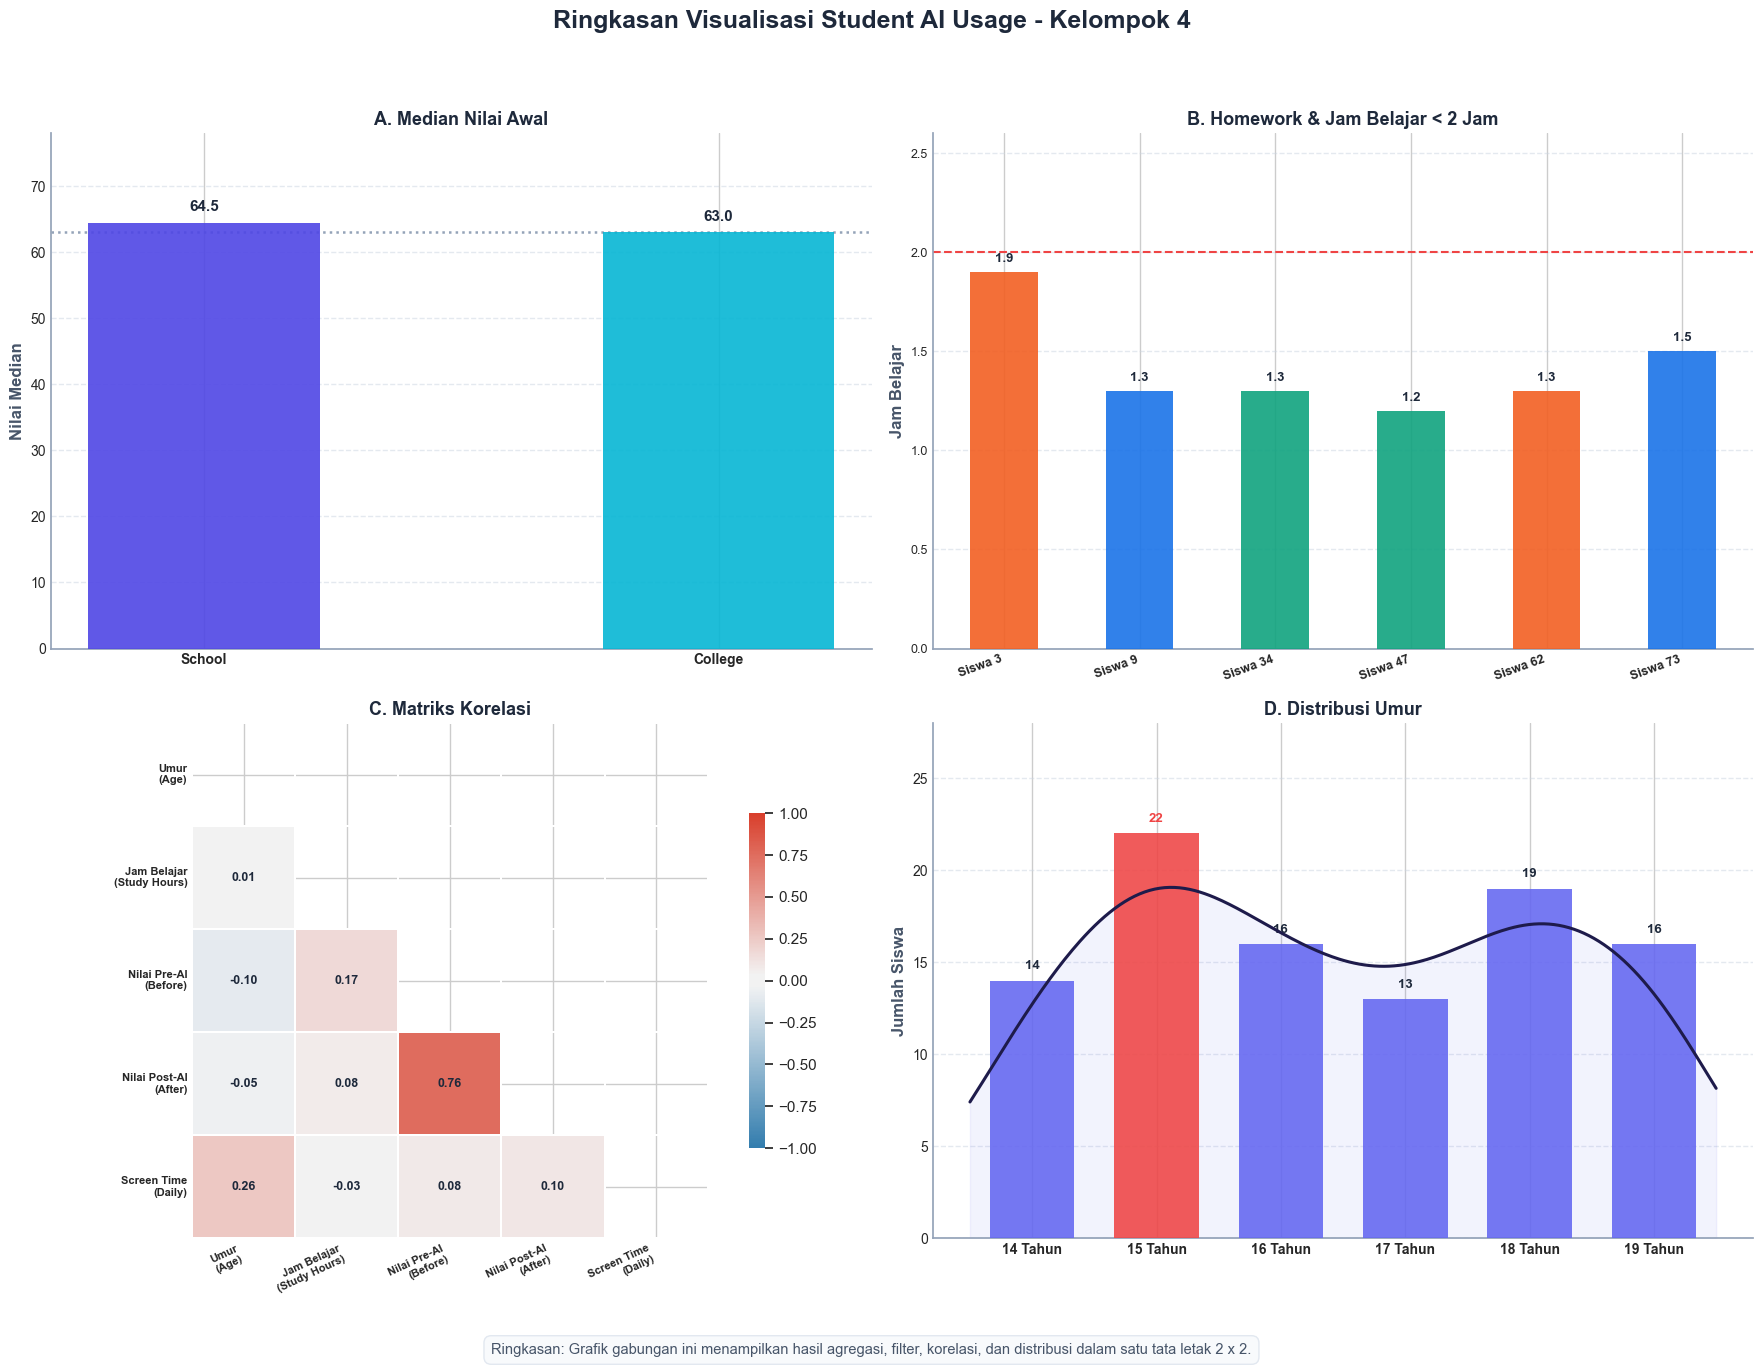

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Ringkasan Visualisasi Student AI Usage - Kelompok 4", fontsize=18, fontweight='bold', color='#1E293B', y=0.98)

# A. Agregasi median nilai awal
ax = axes[0, 0]
bars = ax.bar(
    median_grades["education_level"],
    median_grades["grades_before_ai"],
    color=['#4F46E5', '#06B6D4'],
    width=0.45, edgecolor='none', alpha=0.9, zorder=3
)
style_axis(ax, labelsize=10)
ax.set_xticks(range(len(median_grades)))
ax.set_xticklabels([x.capitalize() for x in median_grades["education_level"]], fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1E293B')
ax.axhline(overall_median, color='#94A3B8', linestyle=':', linewidth=1.8, zorder=2)
ax.set_title("A. Median Nilai Awal", fontsize=13, fontweight='bold', color='#1E293B')
ax.set_ylabel("Nilai Median", fontweight='semibold', color='#475569')
ax.set_ylim(0, 78)

# B. Filter homework dan jam belajar < 2 jam
ax = axes[0, 1]
colors = [tool_colors.get(tool, '#64748B') for tool in filtered['ai_tools_used']]
bars = ax.bar(range(len(filtered)), filtered['study_hours_per_day'], color=colors, width=0.50, edgecolor='none', alpha=0.9, zorder=3)
style_axis(ax, labelsize=9)
ax.set_xticks(range(len(filtered)))
ax.set_xticklabels(filtered['student_label'].tolist(), rotation=20, ha='right', fontweight='semibold')
ax.axhline(2.0, color='#EF4444', linestyle='--', linewidth=1.5, zorder=2)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1E293B')
ax.set_title("B. Homework & Jam Belajar < 2 Jam", fontsize=13, fontweight='bold', color='#1E293B')
ax.set_ylabel("Jam Belajar", fontweight='semibold', color='#475569')
ax.set_ylim(0, 2.6)

# C. Heatmap korelasi triangular
ax = axes[1, 0]
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, vmin=-1.0, vmax=1.0, annot=True, fmt='.2f',
    linewidths=1.3, linecolor='white', square=True, cbar_kws={'shrink': 0.65},
    ax=ax, annot_kws={'size': 9, 'weight': 'bold', 'color': '#1E293B'}
)
ax.set_title("C. Matriks Korelasi", fontsize=13, fontweight='bold', color='#1E293B')
ax.tick_params(axis='both', which='both', length=0, labelsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontweight='semibold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight='semibold')

# D. Distribusi umur dengan peak highlight dan KDE
ax = axes[1, 1]
bars = ax.bar(ages, counts, color=age_colors, width=0.68, edgecolor='none', alpha=0.88, zorder=3)
try:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df['age'])
    x_new = np.linspace(df['age'].min() - 0.5, df['age'].max() + 0.5, 300)
    y_smooth = kde(x_new) * len(df) * 1.0
    ax.plot(x_new, y_smooth, color='#1E1B4B', linewidth=2.2, linestyle='-', zorder=4)
    ax.fill_between(x_new, y_smooth, color='#6366F1', alpha=0.08, zorder=2)
except Exception as e:
    print(f"KDE Overlay skipped: {e}")
style_axis(ax, labelsize=10)
ax.set_xticks(ages)
ax.set_xticklabels([f'{age} Tahun' for age in ages], fontweight='semibold')
for i, bar in enumerate(bars):
    height = bar.get_height()
    is_peak = (i == max_idx)
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=9.5, fontweight='bold' if is_peak else 'semibold', color='#EF4444' if is_peak else '#1E293B')
ax.set_title("D. Distribusi Umur", fontsize=13, fontweight='bold', color='#1E293B')
ax.set_ylabel("Jumlah Siswa", fontweight='semibold', color='#475569')
ax.set_ylim(0, 28)

fig.text(
    0.5, 0.02,
    "Ringkasan: Grafik gabungan ini menampilkan hasil agregasi, filter, korelasi, dan distribusi dalam satu tata letak 2 x 2.",
    ha='center', fontsize=10.5, color='#475569',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8FAFC', edgecolor='#E2E8F0')
)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
save_figure(fig, "05_gabungan_2x2.png")
plt.show()
plt.close(fig)